<a href="https://colab.research.google.com/github/SoumitraDas1/QuantumKAN/blob/main/Test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  **Quark/Gluon Jet Classification using Graph Neural Networks**
  
  Architectures: DGCNN (ParticleNet) and Graph Attention Network (GAT)
  Framework: PyTorch + PyTorch Geometric

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install energyflow numpy scikit-learn matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.2/503.2 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0

# Import Modules

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
from torch_geometric.utils import to_undirected

from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# 1.  CONFIGURATION

In [2]:
class Config:
    # Data
    NUM_SAMPLES    = 100_000   # total jets (50k quark + 50k gluon)
    MAX_PARTICLES  = 50        # truncate/pad each jet to this multiplicity
    K_NEIGHBORS    = 16        # k for kNN graph construction

    # Feature flags
    USE_PDGID      = False     # include PDG ID as a node feature
    EXTRA_FEATURES = True      # add log(pT) and delta_R from jet axis

    # Train / Val / Test split
    TRAIN_FRAC     = 0.70
    VAL_FRAC       = 0.15
    TEST_FRAC      = 0.15

    # Training
    BATCH_SIZE     = 512
    EPOCHS         = 30
    LR             = 1e-3
    WEIGHT_DECAY   = 1e-4
    PATIENCE       = 7         # early-stopping patience

    # Model
    HIDDEN_DIM     = 64
    NUM_CLASSES    = 2

    # Misc
    SEED           = 42
    DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
    SAVE_DIR       = "./checkpoints"
    PLOT_DIR       = "./plots"


cfg = Config()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
os.makedirs(cfg.SAVE_DIR, exist_ok=True)
os.makedirs(cfg.PLOT_DIR, exist_ok=True)

print(f"[Config] Device: {cfg.DEVICE}")

[Config] Device: cuda


# 2.  DATA LOADING  (via EnergyFlow package)

In [3]:
def load_data_energyflow():
    """
    Load the Pythia8 Q/G jet dataset directly from the EnergyFlow library.

    Parameters (hardcoded as specified):
        num_data  = 100000   — 50k quark + 50k gluon jets
        pad       = True     — zero-pad all jets to the same max multiplicity
        ncol      = 4        — keep columns: pt, eta, phi, pdgid
        generator = 'pythia' — use Pythia8 generated events
        with_bc   = False    — exclude b and c quark jets (original EFN paper set)
        cache_dir = '~/.energyflow' — local cache so data is not re-downloaded

    Returns:
        X : np.ndarray  (100000, M, 4)  — particle features per jet
        y : np.ndarray  (100000,)       — 0=gluon, 1=quark
    """
    try:
        import energyflow as ef
    except ImportError:
        raise ImportError("Please run:  pip install energyflow")

    print("[Data] Loading dataset from EnergyFlow library ...")
    X, y = ef.qg_jets.load(num_data=100000, pad=True, ncol=4,
                            generator='pythia', with_bc=False,
                            cache_dir='~/.energyflow')
    print(f"[Data] Loaded {X.shape[0]} jets  |  max multiplicity = {X.shape[1]}  |  features = {X.shape[2]}")
    print(f"[Data] Quark jets: {y.sum():,}  |  Gluon jets: {(1-y).sum():,}")
    return X, y

# 3.  PREPROCESSING & FEATURE ENGINEERING

In [4]:
def preprocess_jet(particles: np.ndarray) -> np.ndarray:
    """
    Convert raw (M, 4) particle array for one jet into a clean feature matrix.

    Steps
    -----
    1. Mask zero-padded particles (pT == 0).
    2. Truncate to MAX_PARTICLES.
    3. Compute jet axis (pT-weighted centroid in eta-phi).
    4. Build feature columns:
         always  : pt  (pT-fraction), eta, phi
         optional: log(pT), delta_R from jet axis, PDGID
    """
    mask  = particles[:, 0] > 0
    ptcs  = particles[mask][:cfg.MAX_PARTICLES]

    if len(ptcs) == 0:
        n_feat = 3 + 2 * int(cfg.EXTRA_FEATURES) + int(cfg.USE_PDGID)
        return np.zeros((1, n_feat), dtype=np.float32)

    pt, eta, phi, pdgid = ptcs[:, 0], ptcs[:, 1], ptcs[:, 2], ptcs[:, 3]

    # pT-weighted jet axis
    pt_sum   = pt.sum() + 1e-8
    eta_axis = (pt * eta).sum() / pt_sum
    phi_axis = (pt * phi).sum() / pt_sum

    features = [pt / pt_sum, eta, phi]      # normalised pT, eta, phi

    if cfg.EXTRA_FEATURES:
        features.append(np.log(pt + 1e-8))
        features.append(np.sqrt((eta - eta_axis)**2 + (phi - phi_axis)**2))

    if cfg.USE_PDGID:
        features.append(pdgid)

    return np.stack(features, axis=1).astype(np.float32)


def knn_graph_edges(pos: np.ndarray, k: int) -> torch.Tensor:
    """
    Build a directed kNN graph in (eta, phi) space.

    Parameters
    ----------
    pos : (N, 2) — (eta, phi) coordinates
    k   : number of nearest neighbours

    Returns
    -------
    edge_index : (2, N*k)  LongTensor
    """
    n = pos.shape[0]
    k = min(k, n - 1)
    if k <= 0:
        return torch.zeros((2, 0), dtype=torch.long)

    diff   = pos[:, None, :] - pos[None, :, :]   # (N, N, 2)
    dist2  = (diff ** 2).sum(-1)                  # (N, N)
    np.fill_diagonal(dist2, np.inf)

    idx   = np.argsort(dist2, axis=1)[:, :k]     # (N, k)
    src   = np.repeat(np.arange(n), k)
    dst   = idx.flatten()

    return torch.tensor(np.stack([src, dst]), dtype=torch.long)


def build_pyg_graph(feat_matrix: np.ndarray, label: int) -> Data:
    """Convert one jet's feature matrix → PyG Data object."""
    x          = torch.tensor(feat_matrix, dtype=torch.float)
    eta_phi    = feat_matrix[:, 1:3]               # columns: eta, phi
    edge_index = knn_graph_edges(eta_phi, cfg.K_NEIGHBORS)
    edge_index = to_undirected(edge_index)
    y          = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)


def build_dataset(X: np.ndarray, y: np.ndarray):
    """Convert raw numpy arrays → list of PyG Data objects."""
    graphs = []
    print("[Preprocessing] Building PyG graphs ...")
    for i in tqdm(range(len(X))):
        feat  = preprocess_jet(X[i])
        graph = build_pyg_graph(feat, int(y[i]))
        graphs.append(graph)
    return graphs

# 4.  ARCHITECTURE 1 – DGCNN  (Dynamic Graph CNN / ParticleNet style)

In [5]:
class EdgeConv(nn.Module):
    """
    EdgeConv block (Wang et al., 2019; Qu & Gouskos, 2020):

        edge_feat_ij = MLP( x_i  ||  (x_j - x_i) )
        x_i'         = max_{j in N(i)}  edge_feat_ij

    The concatenation of x_i (global shape descriptor) and
    (x_j - x_i) (local geometric relation) lets the model learn
    both absolute and relative particle properties simultaneously.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        row, col  = edge_index            # row=target, col=source
        x_i       = x[row]               # central node features
        x_j       = x[col]               # neighbour features
        edge_feat = self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))

        # Scatter-max aggregation (permutation invariant)
        out = torch.zeros(x.size(0), edge_feat.size(-1), device=x.device)
        out.scatter_reduce_(
            0,
            row.unsqueeze(1).expand_as(edge_feat),
            edge_feat,
            reduce="amax",
            include_self=True
        )
        return out


class DGCNN(nn.Module):
    """
    3-layer EdgeConv DGCNN for quark/gluon jet classification.

    Architecture
    ------------
    EdgeConv(64) → EdgeConv(128) → EdgeConv(256)
        ↓
    Concat multi-scale features → GlobalMean + GlobalMax pool
        ↓
    FC(256) → FC(128) → FC(2)

    Graph
    -----
    Pre-built kNN (k=16) in eta-phi for the first layer.
    The same graph is reused across layers for efficiency;
    the EdgeConv MLP still learns expressive higher-order features.
    """
    def __init__(self, in_channels: int, num_classes: int = 2,
                 hidden: int = cfg.HIDDEN_DIM):
        super().__init__()
        self.ec1 = EdgeConv(in_channels,   hidden)
        self.ec2 = EdgeConv(hidden,        hidden * 2)
        self.ec3 = EdgeConv(hidden * 2,    hidden * 4)

        pool_dim = 2 * (hidden + hidden * 2 + hidden * 4)  # mean+max concat

        self.classifier = nn.Sequential(
            nn.Linear(pool_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index, batch = data.x, data.edge_index, data.batch

        h1 = self.ec1(x,  edge_index)
        h2 = self.ec2(h1, edge_index)
        h3 = self.ec3(h2, edge_index)

        # Multi-scale feature aggregation
        h  = torch.cat([h1, h2, h3], dim=-1)
        g  = torch.cat([global_mean_pool(h, batch),
                        global_max_pool(h,  batch)], dim=-1)
        return self.classifier(g)

# 5.  ARCHITECTURE 2 – Graph Attention Network (GAT)

In [6]:
class GATJetClassifier(nn.Module):
    """
    3-layer multi-head GAT for quark/gluon jet classification.

    Architecture
    ------------
    Linear projection (64)
        ↓
    GATConv(8 heads × 16 = 128)  → BN → ELU
        ↓
    GATConv(8 heads × 32 = 256)  → BN → ELU
        ↓
    GATConv(1 head  × 256)       → BN → ELU
        ↓
    GlobalMean + GlobalMax pool  → Concat
        ↓
    FC(256) → Dropout → FC(128) → Dropout → FC(2)

    Attention mechanism (per head)
    ------------------------------
        alpha_ij = softmax_j( LeakyReLU( a^T [ W*x_i || W*x_j ] ) )
        x_i'     = sigma( sum_{j in N(i)} alpha_ij * W * x_j )

    Graph
    -----
    Static kNN (k=16) in eta-phi, shared across all layers.
    Multi-head attention (H=8) captures diverse pairwise interactions
    (e.g., energy flow, collinear splittings, wide-angle radiation).
    """
    def __init__(self, in_channels: int, num_classes: int = 2,
                 hidden: int = cfg.HIDDEN_DIM, heads: int = 8):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU()
        )

        self.gat1 = GATConv(hidden,           hidden,       heads=heads,
                            dropout=0.3, concat=True)
        self.gat2 = GATConv(hidden * heads,   hidden * 2,   heads=heads,
                            dropout=0.3, concat=True)
        self.gat3 = GATConv(hidden * 2 * heads, hidden * 4, heads=1,
                            dropout=0.3, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * 2 * heads)
        self.bn3 = nn.BatchNorm1d(hidden * 4)

        pool_dim = 2 * hidden * 4   # mean + max

        self.classifier = nn.Sequential(
            nn.Linear(pool_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.input_proj(x)
        x = F.elu(self.bn1(self.gat1(x, edge_index)))
        x = F.elu(self.bn2(self.gat2(x, edge_index)))
        x = F.elu(self.bn3(self.gat3(x, edge_index)))

        g = torch.cat([global_mean_pool(x, batch),
                       global_max_pool(x,  batch)], dim=-1)
        return self.classifier(g)

# 6.  TRAINING UTILITIES

In [7]:
class EarlyStopping:
    def __init__(self, patience: int = cfg.PATIENCE, path: str = "best.pt"):
        self.patience  = patience
        self.path      = path
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out   = model(batch)
        loss  = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model(batch)
        loss   = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        prob    = F.softmax(out, dim=1)[:, 1]
        correct += (out.argmax(1) == batch.y).sum().item()
        total   += batch.num_graphs
        all_probs.append(prob.cpu().numpy())
        all_labels.append(batch.y.cpu().numpy())
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return total_loss / total, correct / total, probs, labels


def train_model(model, train_loader, val_loader, name: str):
    model   = model.to(cfg.DEVICE)
    opt     = Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched   = CosineAnnealingLR(opt, T_max=cfg.EPOCHS, eta_min=1e-5)
    crit    = nn.CrossEntropyLoss()
    stopper = EarlyStopping(path=f"{cfg.SAVE_DIR}/{name}_best.pt")
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"\n{'='*62}")
    print(f"  Training: {name}")
    print(f"{'='*62}")

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, tr_acc          = train_one_epoch(model, train_loader, opt, crit, cfg.DEVICE)
        vl_loss, vl_acc, _, _    = evaluate(model, val_loader, crit, cfg.DEVICE)
        sched.step()
        stopper.step(vl_loss, model)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"  Epoch {epoch:03d}/{cfg.EPOCHS} | "
              f"Train  loss={tr_loss:.4f}  acc={tr_acc:.4f} | "
              f"Val  loss={vl_loss:.4f}  acc={vl_acc:.4f}")

        if stopper.stop:
            print(f"  [EarlyStopping] Stopped at epoch {epoch}.")
            break

    # Reload best weights
    model.load_state_dict(
        torch.load(f"{cfg.SAVE_DIR}/{name}_best.pt", map_location=cfg.DEVICE)
    )
    return model, history

# 7.  EVALUATION & VISUALISATION

In [8]:
COLORS = {"DGCNN": "#E87722", "GAT": "#1A73E8"}


def plot_training_curves(histories: dict):
    n    = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (name, hist) in enumerate(histories.items()):
        c      = COLORS.get(name, "steelblue")
        epochs = range(1, len(hist["train_loss"]) + 1)

        axes[i][0].plot(epochs, hist["train_loss"], label="Train", color=c, lw=2)
        axes[i][0].plot(epochs, hist["val_loss"],   label="Val",   color=c, lw=2, ls="--")
        axes[i][0].set_title(f"{name} — Loss", fontsize=13, fontweight="bold")
        axes[i][0].set_xlabel("Epoch"); axes[i][0].set_ylabel("Cross-Entropy Loss")
        axes[i][0].legend(); axes[i][0].grid(alpha=0.3)

        axes[i][1].plot(epochs, hist["train_acc"], label="Train", color=c, lw=2)
        axes[i][1].plot(epochs, hist["val_acc"],   label="Val",   color=c, lw=2, ls="--")
        axes[i][1].set_title(f"{name} — Accuracy", fontsize=13, fontweight="bold")
        axes[i][1].set_xlabel("Epoch"); axes[i][1].set_ylabel("Accuracy")
        axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

    plt.tight_layout()
    path = f"{cfg.PLOT_DIR}/training_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {path}")


def plot_roc_curves(results: dict):
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
        roc_auc      = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2.5, color=COLORS.get(name, "gray"),
                label=f"{name}  (AUC = {roc_auc:.4f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random (AUC = 0.50)")
    ax.set_xlabel("False Positive Rate (Gluon tagged as Quark)", fontsize=12)
    ax.set_ylabel("True Positive Rate (Quark Efficiency)", fontsize=12)
    ax.set_title("ROC Curve — Quark/Gluon Jet Classification", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3)
    plt.tight_layout()
    path = f"{cfg.PLOT_DIR}/roc_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {path}")


def plot_confusion_matrices(results: dict):
    n    = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        preds = (res["probs"] >= 0.5).astype(int)
        cm    = confusion_matrix(res["labels"], preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Gluon", "Quark"],
                    yticklabels=["Gluon", "Quark"],
                    annot_kws={"size": 14})
        ax.set_title(f"{name} — Confusion Matrix", fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    plt.tight_layout()
    path = f"{cfg.PLOT_DIR}/confusion_matrices.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {path}")


def plot_score_distributions(results: dict):
    n    = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        probs, labels = res["probs"], res["labels"]
        ax.hist(probs[labels == 0], bins=50, alpha=0.6, density=True,
                color="#1A73E8", label="Gluon (y=0)")
        ax.hist(probs[labels == 1], bins=50, alpha=0.6, density=True,
                color="#E87722", label="Quark (y=1)")
        ax.set_title(f"{name} — Score Distribution", fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted Quark Probability"); ax.set_ylabel("Density")
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    path = f"{cfg.PLOT_DIR}/score_distributions.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {path}")


def print_summary_table(results: dict):
    print("\n" + "=" * 72)
    print(f"{'Model':<12} {'Accuracy':>10} {'AUC':>10} {'Gluon-Rej@50%eff':>18}")
    print("=" * 72)
    for name, res in results.items():
        labels = res["labels"]; probs = res["probs"]
        preds  = (probs >= 0.5).astype(int)
        acc    = accuracy_score(labels, preds)
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc     = auc(fpr, tpr)
        idx50       = np.argmin(np.abs(tpr - 0.50))
        gluon_rej   = 1.0 / (fpr[idx50] + 1e-9)
        print(f"{name:<12} {acc:>10.4f} {roc_auc:>10.4f} {gluon_rej:>18.1f}")

    print("=" * 72)
    for name, res in results.items():
        preds = (res["probs"] >= 0.5).astype(int)
        print(f"\n  [{name}] Classification Report:")
        print(classification_report(res["labels"], preds,
                                    target_names=["Gluon", "Quark"], digits=4))


# 8.  MAIN PIPELINE

In [9]:
def main():
    # ── Load real data directly from EnergyFlow library ─────────────────────
    X, y = load_data_energyflow()

    # ── Build PyG graph list ──────────────────────────────────────────────────
    graphs = build_dataset(X, y)

    in_channels = graphs[0].x.shape[1]
    print(f"[Info] Node feature dimension = {in_channels}")

    # ── Stratified splits ─────────────────────────────────────────────────────
    idx             = np.arange(len(graphs))
    idx_tr, idx_tmp = train_test_split(idx,
                                       test_size=1 - cfg.TRAIN_FRAC,
                                       random_state=cfg.SEED,
                                       stratify=y)
    idx_vl, idx_te  = train_test_split(idx_tmp,
                                       test_size=cfg.TEST_FRAC /
                                                 (cfg.TEST_FRAC + cfg.VAL_FRAC),
                                       random_state=cfg.SEED,
                                       stratify=y[idx_tmp])

    train_graphs = [graphs[i] for i in idx_tr]
    val_graphs   = [graphs[i] for i in idx_vl]
    test_graphs  = [graphs[i] for i in idx_te]

    print(f"[Split] Train={len(train_graphs)}  Val={len(val_graphs)}  Test={len(test_graphs)}")

    train_loader = DataLoader(train_graphs, batch_size=cfg.BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_graphs,   batch_size=cfg.BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_graphs,  batch_size=cfg.BATCH_SIZE, shuffle=False)

    # ── Instantiate models ────────────────────────────────────────────────────
    dgcnn = DGCNN(in_channels=in_channels, num_classes=cfg.NUM_CLASSES,
                  hidden=cfg.HIDDEN_DIM)
    gat   = GATJetClassifier(in_channels=in_channels, num_classes=cfg.NUM_CLASSES,
                              hidden=cfg.HIDDEN_DIM, heads=8)

    print(f"\n[Model] DGCNN params : {sum(p.numel() for p in dgcnn.parameters()):,}")
    print(f"[Model] GAT   params : {sum(p.numel() for p in gat.parameters()):,}")

    # ── Train ─────────────────────────────────────────────────────────────────
    dgcnn, dgcnn_hist = train_model(dgcnn, train_loader, val_loader, "DGCNN")
    gat,   gat_hist   = train_model(gat,   train_loader, val_loader, "GAT")

    # ── Test-set evaluation ───────────────────────────────────────────────────
    crit    = nn.CrossEntropyLoss()
    results = {}
    histories = {"DGCNN": dgcnn_hist, "GAT": gat_hist}

    print("\n[Evaluation] Test set results:")
    for name, model in [("DGCNN", dgcnn), ("GAT", gat)]:
        _, acc, probs, labels = evaluate(model, test_loader, crit, cfg.DEVICE)
        results[name] = {"probs": probs, "labels": labels}
        print(f"  {name:8s} | Test Accuracy = {acc:.4f}")

    # ── Plots ─────────────────────────────────────────────────────────────────
    plot_training_curves(histories)
    plot_roc_curves(results)
    plot_confusion_matrices(results)
    plot_score_distributions(results)
    print_summary_table(results)

[Data] Loading dataset from EnergyFlow library ...
[Data] Loaded 100000 jets  |  max multiplicity = 139  |  features = 4
[Data] Quark jets: 50,000.0  |  Gluon jets: 50,000.0
[Preprocessing] Building PyG graphs ...


100%|██████████| 100000/100000 [01:11<00:00, 1400.05it/s]


[Info] Node feature dimension = 5
[Split] Train=69999  Val=15000  Test=15001

[Model] DGCNN params : 434,050
[Model] GAT   params : 993,026

  Training: DGCNN
  Epoch 001/30 | Train  loss=0.5333  acc=0.7365 | Val  loss=0.4999  acc=0.7639
  Epoch 002/30 | Train  loss=0.4889  acc=0.7759 | Val  loss=0.4668  acc=0.7877
  Epoch 003/30 | Train  loss=0.4819  acc=0.7798 | Val  loss=0.4614  acc=0.7915
  Epoch 004/30 | Train  loss=0.4727  acc=0.7878 | Val  loss=0.4643  acc=0.7922
  Epoch 005/30 | Train  loss=0.4682  acc=0.7909 | Val  loss=0.4621  acc=0.7845
  Epoch 006/30 | Train  loss=0.4637  acc=0.7922 | Val  loss=0.4810  acc=0.7694
  Epoch 007/30 | Train  loss=0.4582  acc=0.7978 | Val  loss=0.4572  acc=0.7989
  Epoch 008/30 | Train  loss=0.4542  acc=0.7987 | Val  loss=0.4520  acc=0.7997
  Epoch 009/30 | Train  loss=0.4509  acc=0.8016 | Val  loss=0.4770  acc=0.7913
  Epoch 010/30 | Train  loss=0.4484  acc=0.8017 | Val  loss=0.4882  acc=0.7799
  Epoch 011/30 | Train  loss=0.4479  acc=0.8029 | V

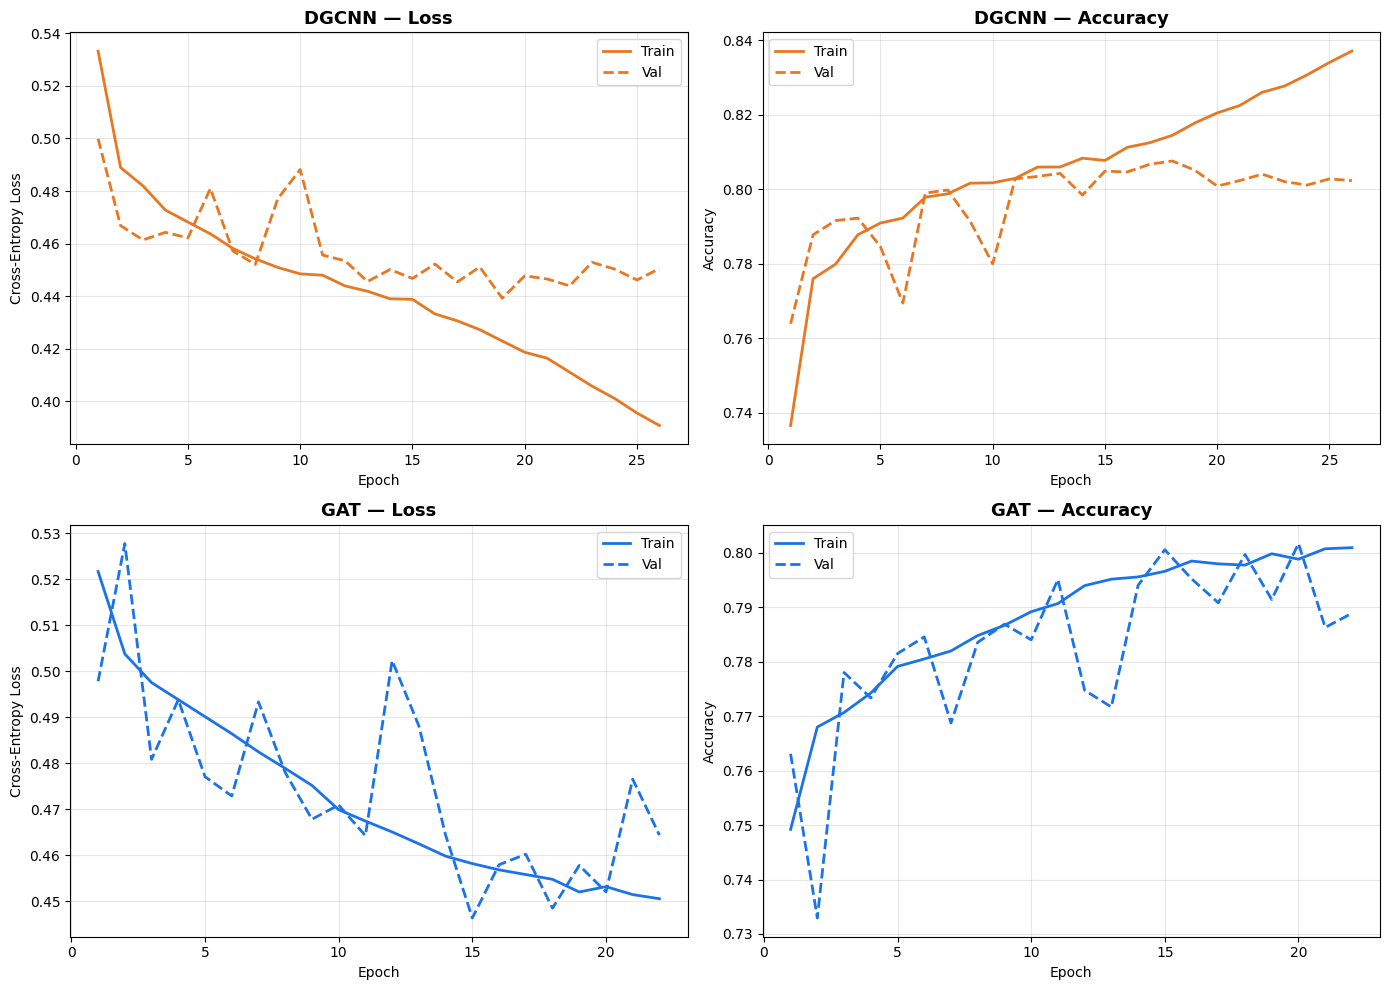

[Plot] Saved → ./plots/training_curves.png


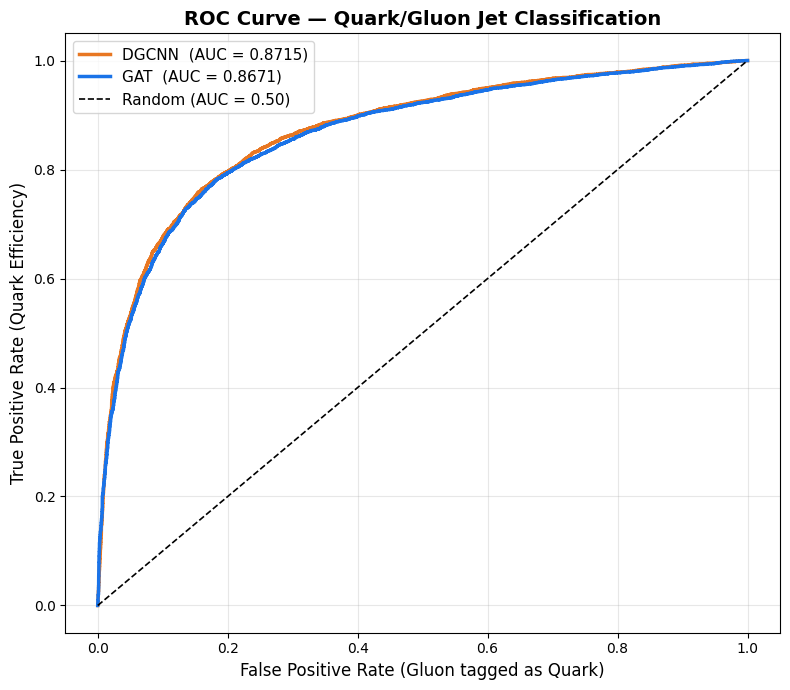

[Plot] Saved → ./plots/roc_curves.png


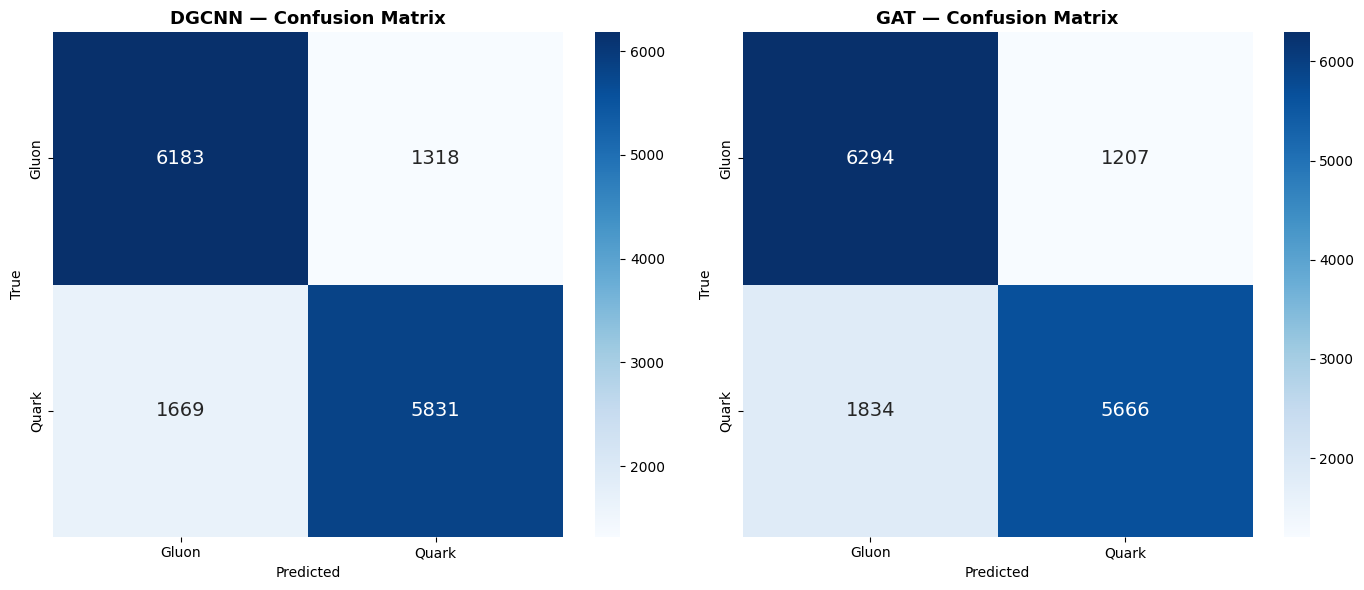

[Plot] Saved → ./plots/confusion_matrices.png


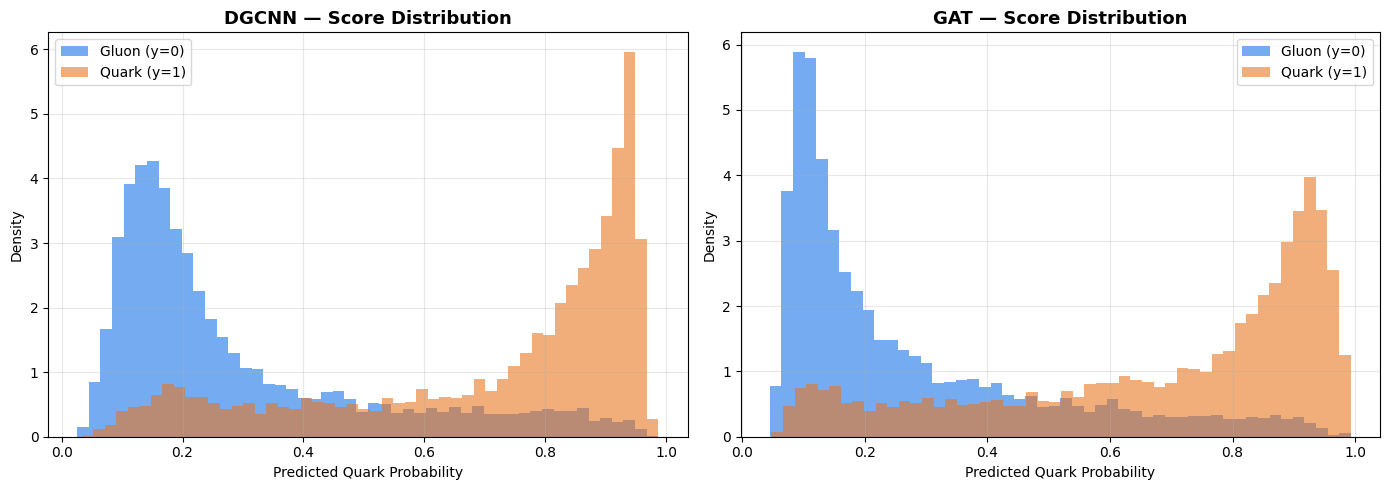

[Plot] Saved → ./plots/score_distributions.png

Model          Accuracy        AUC   Gluon-Rej@50%eff
DGCNN            0.8009     0.8715               24.2
GAT              0.7973     0.8671               22.7

  [DGCNN] Classification Report:
              precision    recall  f1-score   support

       Gluon     0.7874    0.8243    0.8054      7501
       Quark     0.8156    0.7775    0.7961      7500

    accuracy                         0.8009     15001
   macro avg     0.8015    0.8009    0.8008     15001
weighted avg     0.8015    0.8009    0.8008     15001


  [GAT] Classification Report:
              precision    recall  f1-score   support

       Gluon     0.7744    0.8391    0.8054      7501
       Quark     0.8244    0.7555    0.7884      7500

    accuracy                         0.7973     15001
   macro avg     0.7994    0.7973    0.7969     15001
weighted avg     0.7994    0.7973    0.7969     15001



In [10]:
main()